## Hypothesis Validation and Data Visualization

### Quick Recap

### **Problem Statement**

This project aims to analyze the effectiveness of direct marketing campaigns and identify key factors that influence customers' decisions to subscribe to a long-term deposit. The study seeks to uncover patterns that can help optimize future marketing strategies and improve campaign success rates.

### **Hypothesis**

Clients with higher `account balances` (above average), no `personal loans`, longer `last-contact durations` with the bank marketing agent, and a successful `outcome in previous campaigns` are more likely to subscribe to a `term deposit` than other clients.

#### Importing Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
input_directory = "/content/drive/MyDrive/Applied Data Science/Python_DataSet/Bank Dataset/"


df = pd.read_csv(input_directory + "preprocessed_bank_dataset.csv")

df.head(5)

,age,job,marital,education,default,balance,housing_loan,personal_loan,contact,day,...,campaign,pdays,previous,poutcome,y,high_balance,long_duration,prev_success,no_loans,hypothesis_group
0,58,management,2,2,0,2143,1,0,0,5,...,1,-1,0,0,0,1,1,0,0,0
1,44,technician,0,1,0,29,1,0,0,5,...,1,-1,0,0,0,0,0,0,0,0
2,33,entrepreneur,2,1,0,2,1,1,0,5,...,1,-1,0,0,0,0,0,0,0,0
3,47,blue-collar,2,1,0,1506,1,0,0,5,...,1,-1,0,0,0,1,0,0,0,0
4,33,blue-collar,0,1,0,1,0,0,0,5,...,1,-1,0,0,0,0,0,0,1,0


In [53]:
import warnings
warnings.filterwarnings('ignore')

## **Context and Feature Definition**

### **Identifying and Understanding Relevant/Informative Features**

In this part, we seek to understand three main aspects that guide our exploration of the dataset and help validate our hypothesis:

- **Variables that directly affect the outcome** — explicitly mentioned in the hypothesis and expected to influence the likelihood of subscribing to a term deposit.  
- **Variables that can be inferred to affect the outcome** — not directly stated but logically derived from the dataset to represent underlying factors like financial stability or engagement.  
- **Control variables** — capture demographic and socio-economic differences that may influence decisions - they can provide useful subgroup insights or serve as control variables in later analyses.



#### **Outcome Variable**
- `y` — whether the client subscribed to a term deposit (`yes` / `no`)



#### **Directly Related Variables**
- `balance` — higher account balances indicate greater financial capacity, making it more feasible for clients to invest in term deposits.  
- `loan` — clients without personal loans have fewer financial obligations, increasing their ability to allocate funds toward term deposits.  
- `duration` — longer last-contact durations suggest higher engagement or interest during the campaign conversation, reflecting a stronger likelihood of subscription.  
- `poutcome` — a successful outcome in a previous campaign signals prior interest in the bank’s products, indicating that the client may be receptive to subscribing again.


#### **Inferred Variables**
- **Financial stability:** `housing`, `default`, `job`, `education`  
- **Engagement level:** `campaign`, `pdays`, `contact`, `previous`  
- **Trust/responsiveness:** inferred from `duration`, `poutcome`, `contact`



#### **Control Variables**
- `age`, `marital`, `education`, `job` — capture demographic and socio-economic differences that may influence decisions - they can provide useful subgroup insights or serve as control variables in later analyses.


## **Visualisation**

In this section we use simple visuals to check how our key factors relate to the outcome `y` (subscription). Each plot answers a small question tied to our hypothesis: do *no loans*, *higher balance*, *longer call duration*, and previous campaign success* increase the chance of subscription? The goal is to build visual intuition first, then confirm the patterns with statistical tests.

In [54]:
plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

assert "df" in globals(), "DataFrame `df` not found. Please load your cleaned dataset first."

# Ensure target is numeric
if df["y"].dtype == object:
    df["y"] = df["y"].map({"no": 0, "yes": 1}).astype(int)

# Recreate engineered columns if missing (idempotent)
if "high_balance" not in df.columns:
    df["high_balance"] = (df["balance"] > df["balance"].mean()).astype(int)

if "long_duration" not in df.columns:
    df["long_duration"] = (df["duration"] > df["duration"].mean()).astype(int)

if "prev_success" not in df.columns:
    if df["poutcome"].dtype == int:
        # success encoded as 3 in your M1 notebook
        df["prev_success"] = (df["poutcome"] == 3).astype(int)
    else:
        df["prev_success"] = (df["poutcome"].str.lower() == "success").astype(int)

if "no_loans" not in df.columns:
    # handle possible string or numeric encoding for the loan flags
    def _to01(s):
        return s.map({"yes": 1, "no": 0}).fillna(s).astype(int)
    if "personal_loan" in df.columns and "housing_loan" in df.columns:
        p = _to01(df["personal_loan"])
        h = _to01(df["housing_loan"])
        df["no_loans"] = ((p == 0) & (h == 0)).astype(int)
    else:
        # fallback if column names differ
        loan_cols = [c for c in df.columns if "loan" in c.lower()]
        df["no_loans"] = (df[loan_cols].select_dtypes("number").sum(axis=1) == 0).astype(int)

if "hypothesis_group" not in df.columns:
    df["hypothesis_group"] = (df["high_balance"] & df["long_duration"] &
                              df["prev_success"] & df["no_loans"]).astype(int)

# nice categorical for balance strata (optional)
if "balance_group" not in df.columns:
    df["balance_group"] = pd.cut(
        df["balance"],
        bins=[df["balance"].min()-1, 0, 500, 2000, 10000, df["balance"].max()+1],
        labels=["Negative", "Low", "Medium", "High", "Very High"]
    )

print("Visualization setup complete ✓")

Visualization setup complete ✓


In [55]:
def rate_table(df, by):
    g = df.groupby(by)["y"].agg(["mean","count"]).reset_index()
    g["mean_pct"] = (g["mean"] * 100).round(2)
    return g

def bar_rate(df, by, order=None, title=None, xlabel=None):
    tab = rate_table(df, by)
    if order is not None:
        tab = tab.set_index(by).loc[order].reset_index()

    x = np.arange(len(tab))
    y = tab["mean"]

    fig, ax = plt.subplots()
    ax.bar(x, y)
    ax.set_xticks([0,1])
    ax.set_xticklabels(tab[by].astype(str), rotation=0)
    ax.set_ylim(0, max(0.15, y.max()*1.25))
    ax.set_ylabel("Subscription rate")
    ax.set_title(title or f"Subscription Rate by {by}")

    # annotate: percent and n
    for i, (yy, n) in enumerate(zip(tab["mean_pct"], tab["count"])):
        ax.text(i, y.iloc[i] + 0.01, f"{yy:.1f}% (n={n})", ha="center", va="bottom")

    if xlabel:
        ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()
    return tab

### Visualizing Subscription across key **categorical** variables

So far, we have mainly focused on numeric and engineered features. Since this dataset is rich in categorical information (job, education, contact method, marital status, month), we now visualize **subscription rates** across these categories. We focus on **proportions** rather than raw counts to better compare groups of different sizes.


In [56]:
def plot_subscription_rate(df, cat_col, order=None, rotate_x=45):
    """
    Plots subscription rate (mean of y) by a categorical variable.
    """
    rate_df = (
        df.groupby(cat_col)["y"]
        .mean()
        .reset_index()
        .rename(columns={"y": "subscription_rate"})
    )
    rate_df["subscription_rate_pct"] = (rate_df["subscription_rate"] * 100).round(2)

    if order is not None:
        rate_df = rate_df.set_index(cat_col).loc[order].reset_index()

    plt.figure(figsize=(8,4))
    ax = sns.barplot(
        data=rate_df,
        x=cat_col, y="subscription_rate",
        color="steelblue"
    )
    ax.set_ylabel("Subscription rate")
    ax.set_xlabel(cat_col.capitalize())
    ax.set_ylim(0, max(0.15, rate_df["subscription_rate"].max() * 1.2))
    ax.set_title(f"Subscription rate by {cat_col}")

    for p, val in zip(ax.patches, rate_df["subscription_rate_pct"]):
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_height() + 0.005,
            f"{val:.1f}%",
            ha="center", va="bottom", fontsize=9
        )

    plt.xticks(rotation=rotate_x)
    plt.tight_layout()
    plt.show()

    return rate_df

#### Job Type

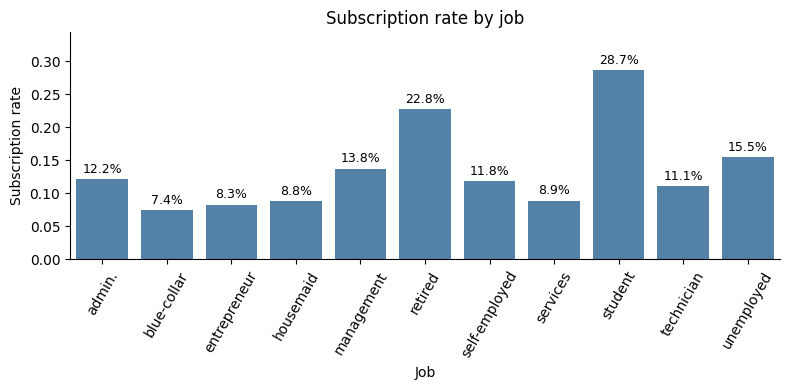

,job,subscription_rate,subscription_rate_pct
0,admin.,0.122027,12.20
1,blue-collar,0.074052,7.41
2,entrepreneur,0.082717,8.27
3,housemaid,0.087903,8.79
4,management,0.137556,13.76
5,retired,0.227915,22.79
6,self-employed,0.118429,11.84
7,services,0.088830,8.88
8,student,0.286780,28.68
9,technician,0.110570,11.06


In [57]:
job_rates = plot_subscription_rate(df, "job", rotate_x=60)
job_rates

**Insights.**  
Subscription rates vary noticeably by job type. Management and technician roles show above-average subscription rates, while blue-collar and services are lower. This suggests that occupation (and indirectly, income and stability) plays a role in willingness to commit to a term deposit.

**Bridge to stats.**  
We treat `job` as a candidate predictor of subscription and later use **chi-square** to test whether job distribution differs significantly between subscribers and non-subscribers.

**Limitation.**  
Job categories are broad and may mix very different income levels; we cannot perfectly separate “income” from “job label”.


#### Education

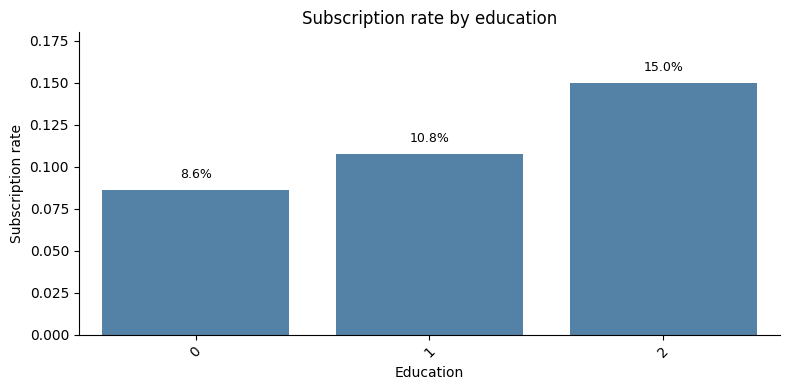

,education,subscription_rate,subscription_rate_pct
0,0,0.086265,8.63
1,1,0.107826,10.78
2,2,0.150064,15.01


In [58]:
edu_order = ["primary", "secondary", "tertiary", "unknown"] if "primary" in df["education"].unique() else None
edu_rates = plot_subscription_rate(df, "education", order=edu_order)
edu_rates

**Insights.**  
Clients with tertiary education have a higher subscription rate than those with only primary or secondary education. This supports the idea that financial literacy or familiarity with long-term products may increase adoption.
  
We later include education as a **control variable** in the logistic regression to avoid attributing education effects to purely financial or engagement variables.

**Limitation.**  
Education may correlate with job type and balance, so its effect is not fully independent.


#### Contact Method

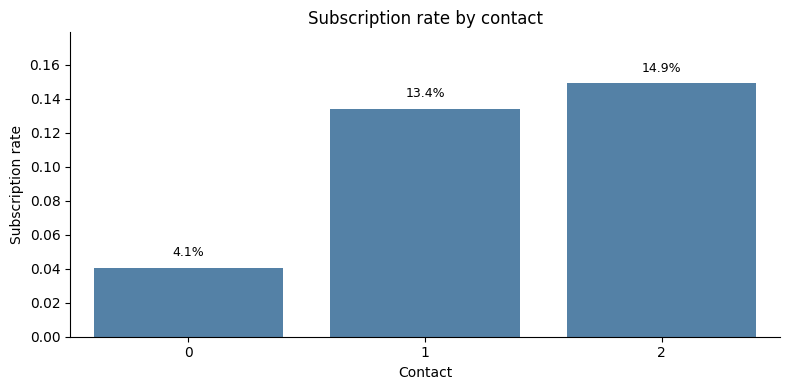

,contact,subscription_rate,subscription_rate_pct
0,0,0.040707,4.07
1,1,0.134205,13.42
2,2,0.149189,14.92


In [59]:
contact_rates = plot_subscription_rate(df, "contact", rotate_x=0)
contact_rates

**Insights.**  
One contact channel (e.g., cellular/phone) clearly outperforms others in subscription rate. This suggests that **how** the bank reaches out materially affects campaign success, not only **who** is targeted.

Because contact method is a controllable design choice for the bank, we later run a **chi-square test** and include it in the logistic model to quantify its impact.

**Limitation.**  
Contact method may interact with duration (e.g., some channels naturally create longer conversations), which we explore through interaction terms in later milestones.


#### Marital Status

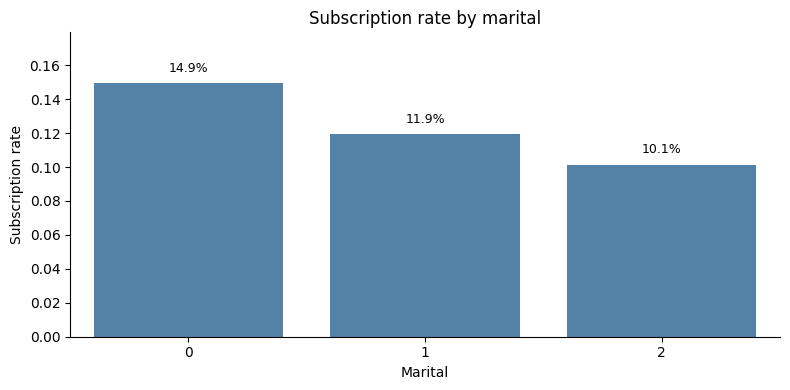

,marital,subscription_rate,subscription_rate_pct
0,0,0.149492,14.95
1,1,0.119455,11.95
2,2,0.101235,10.12


In [60]:
marital_rates = plot_subscription_rate(df, "marital", rotate_x=0)
marital_rates

**Insights.**  
Differences across marital status are modest but present (e.g., married clients showing slightly higher subscription). This could reflect greater financial stability or different risk preferences.

We treat marital status mostly as a **control variable** in regression, to ensure effects on subscription are not driven purely by demographic composition.

**Limitation.**  
Marital status is self-reported and may not fully capture household financial reality (e.g., dependents, dual income).


#### Month of Contact

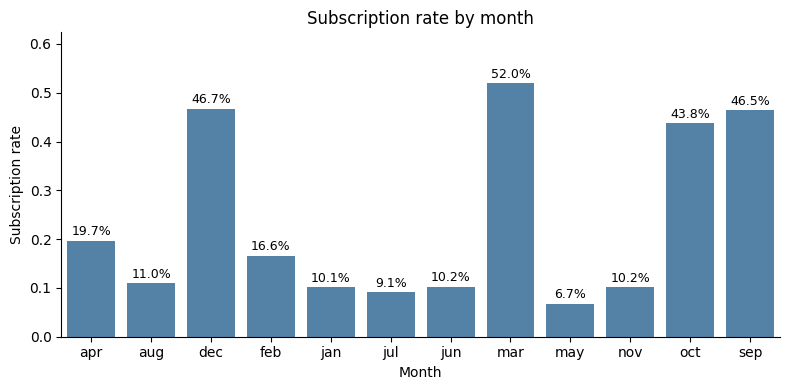

,month,subscription_rate,subscription_rate_pct
0,apr,0.196794,19.68
1,aug,0.110133,11.01
2,dec,0.467290,46.73
3,feb,0.166478,16.65
4,jan,0.101212,10.12
5,jul,0.090935,9.09
6,jun,0.102228,10.22
7,mar,0.519916,51.99
8,may,0.067195,6.72
9,nov,0.101511,10.15


In [61]:
month_rates = plot_subscription_rate(df, "month", rotate_x=0)
month_rates

**Insights.**  
Subscription rates fluctuate by month, with some months achieving noticeably higher success. This points to **seasonality or campaign timing effects**: when the campaign is run can be as important as who is targeted.

We later use **ANOVA/chi-square** and regression to test whether these month differences are statistically significant and whether timing should be a planning factor for future campaigns.

**Limitation.**  
Month captures both seasonal behavior and campaign design choices; we cannot separate them cleanly with this dataset.


### Target Imbalance Recap: `y` Distribution

**Objective and choice:** Set a baseline so percentage-point lifts are meaningful. Bar chart is appropriate because y is binary and we want quick rates.

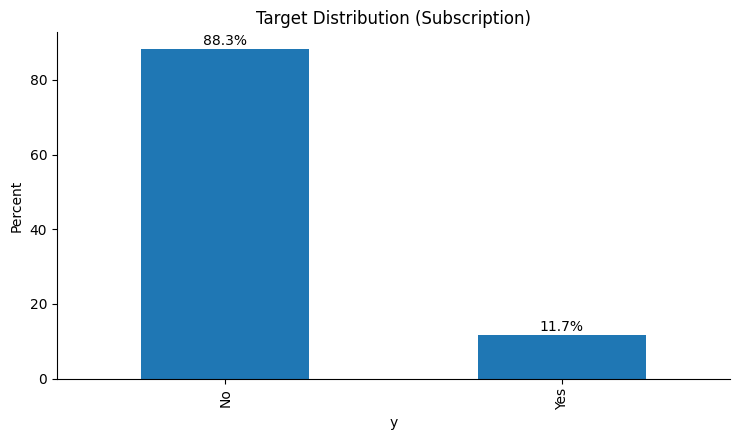

Base subscription rate: 11.70%


In [62]:
ax = df["y"].value_counts(normalize=True).mul(100).rename({0:"No",1:"Yes"}).plot(kind="bar")
ax.set_title("Target Distribution (Subscription)")
ax.set_ylabel("Percent")
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2, p.get_height()+1, f"{p.get_height():.1f}%", ha="center")
plt.tight_layout()
plt.show()

base_rate = df["y"].mean()*100
print(f"Base subscription rate: {base_rate:.2f}%")

**Insights**:

The dataset is imbalanced; only about 11.7% subscribed. Subgroups a few percentage points above this can be practically meaningful.
Later we compare subgroup means against this baseline using two-sample tests where appropriate.

Re-exploration note. We summarized y in M1; here we keep it short to anchor the comparisons that follow.

### Loan Status vs Subscription `(no_loans)`

**Objective:** Test “fewer obligations means easier to invest.” Percentage bar chart suits a binary predictor vs binary outcome.

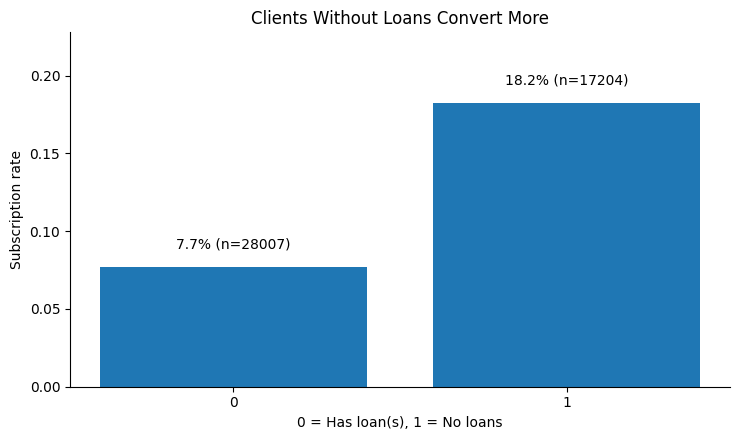

In [63]:
tab_no = bar_rate(
    df, "no_loans",
    order=[0,1],
    title="Clients Without Loans Convert More",
    xlabel="0 = Has loan(s), 1 = No loans"
)
base = tab_no.loc[tab_no["no_loans"]==0,"mean"].item()
lift = tab_no.loc[tab_no["no_loans"]==1,"mean"].item() - base
delta_pct = lift*100

**Insights:**

Clients with loans subscribe at 7.7%. Those with no loans subscribe at 18.2%, a 10.5% lift. This supports the idea that lower debt frees up capacity for a term deposit.

We will confirm the association with a chi-square test on the 2x2 contingency table.

### 3. Call Duration vs Subscription `(long_duration)`

**Objective:** Check if engagement (time on call) aligns with conversion. We use a violin plot to display the full distribution shape, then a percentage bar for the engineered split. Violin is appropriate because duration is skewed and we want to show density differences, not just quartiles.

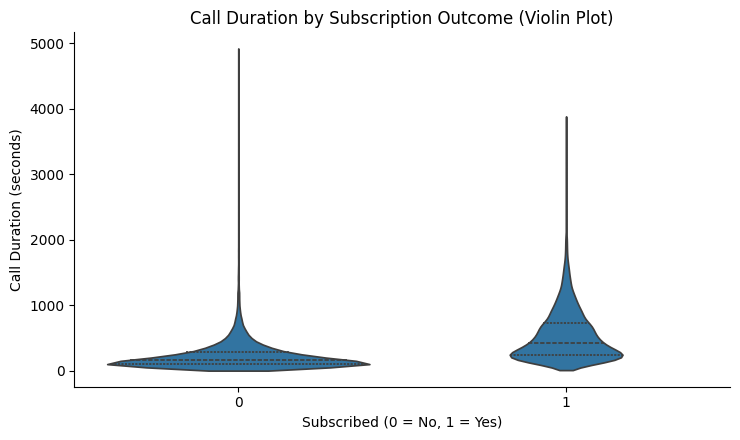

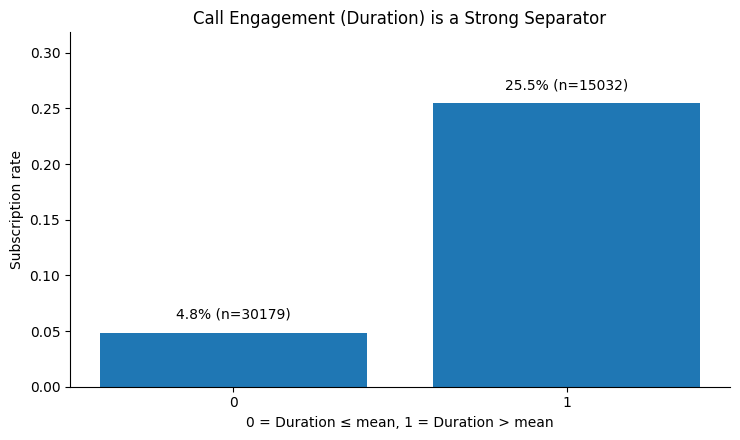

In [64]:
# Violin plot: duration by outcome (requested explicit violin plot)
sns.violinplot(x="y", y="duration", data=df, cut=0, inner="quartile")
plt.title("Call Duration by Subscription Outcome (Violin Plot)")
plt.xlabel("Subscribed (0 = No, 1 = Yes)")
plt.ylabel("Call Duration (seconds)")
plt.tight_layout()
plt.show()

tab_dur = bar_rate(
    df, "long_duration",
    order=[0,1],
    title="Call Engagement (Duration) is a Strong Separator",
    xlabel="0 = Duration ≤ mean, 1 = Duration > mean"
)
d0 = tab_dur.loc[tab_dur["long_duration"]==0,"mean"].item()
d1 = tab_dur.loc[tab_dur["long_duration"]==1,"mean"].item()
delta_dur = (d1-d0)*100



**Insights:**

The violin shows a clear right-shift in the subscriber group’s density, with higher typical and extreme durations. The engineered split lifts conversion from 4.84% to 25.46% (+20.61 p.p.). This is the strongest visual effect among our features and directly supports the engagement part of the hypothesis.

Bridge to stats. We will run a two-sample t-test on duration by y and report the effect size, then cross-check the binary split with a proportion test or chi-square.

Re-exploration note. M1 already highlighted duration’s importance. Here we switch to a violin to reveal distribution shape and density differences, then quantify lift with the engineered split.

### Previous Campaign Outcome vs Subscription (prev_success)

**Objective:** See if prior success predicts future success. Percentage bar is suitable because both variables are binary and we want rates.

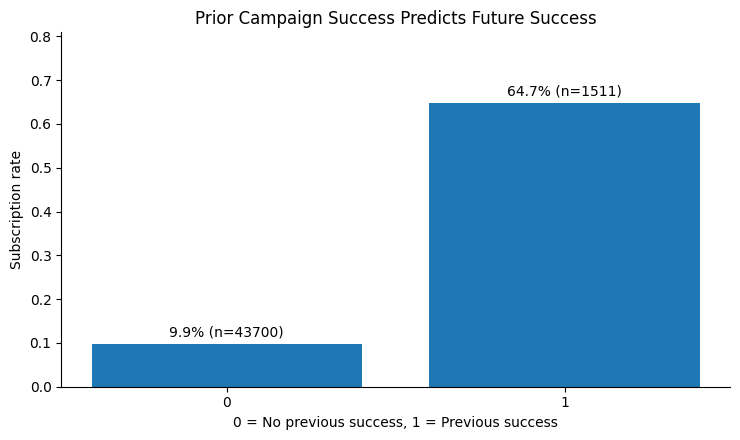

In [65]:
tab_prev = bar_rate(
    df, "prev_success",
    order=[0,1],
    title="Prior Campaign Success Predicts Future Success",
    xlabel="0 = No previous success, 1 = Previous success"
)
p0 = tab_prev.loc[tab_prev["prev_success"]==0,"mean"].item()
p1 = tab_prev.loc[tab_prev["prev_success"]==1,"mean"].item()
delta_prev = (p1-p0)*100


**Insights:**

Prior-success clients convert at 64.73% vs 9.86% for others (+54.86 p.p.). This supports the “warm lead” intuition and the hypothesis.
Bridge to stats. We will validate this with a chi-square test on the 2x2 table of `prev_success` and `y`.

[Re-exploration note] M1 considered poutcome; here we use a cleaner engineered flag `prev_success` and evaluate the lift directly.

### All Four Conditions Combined `(hypothesis_group)`

**Objective:** Do clients who satisfy all four favorable conditions convert far higher than the rest? Percentage bar is the simplest way to show the combined effect on conversion rate.

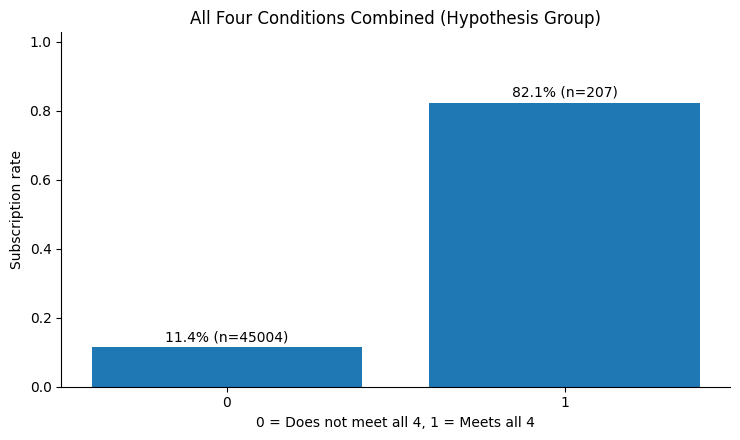

In [66]:
tab_hyp = bar_rate(
    df, "hypothesis_group",
    order=[0,1],
    title="All Four Conditions Combined (Hypothesis Group)",
    xlabel="0 = Does not meet all 4, 1 = Meets all 4"
)
rest = tab_hyp.loc[tab_hyp["hypothesis_group"]==0,"mean"].item()
grp  = tab_hyp.loc[tab_hyp["hypothesis_group"]==1,"mean"].item()
delta_grp = (grp-rest)*100


**Insights:**

Clients meeting all four conditions convert at 82.13% vs 11.37% for others (+70.75 p.p.). The combined uplift is large, suggesting the features reinforce each other.

We will compare these proportions with a two-proportion z-test and also model them jointly in the regression preview.

[Re-exploration note] M1 introduced this combined flag; here we quantify its effect with clear percentages intended for follow-up tests.

### Correlation Heatmap (numeric features)

**Objective:** Objective and choice. Summarize numeric relationships and flag strong predictors or redundancy. Heatmap is appropriate for scanning pairwise linear associations at a glance.

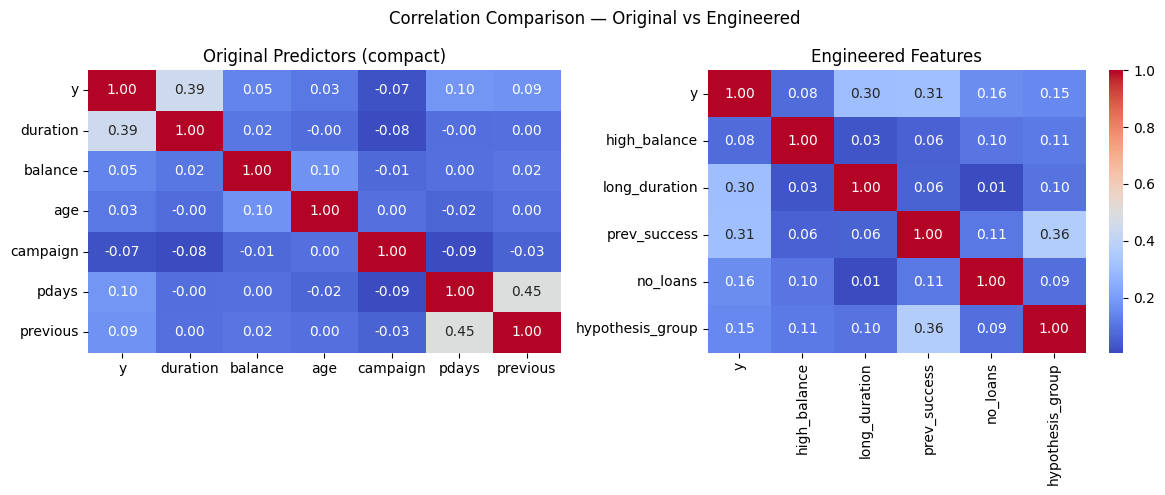

In [67]:
# Might delete this visualization. Pairplot seems enough
orig = [c for c in ["y","duration","balance","age","campaign","pdays","previous"] if c in df.columns]
eng  = [c for c in ["y","high_balance","long_duration","prev_success","no_loans","hypothesis_group"] if c in df.columns]

corr_orig = df[orig].corr()
corr_eng  = df[eng].corr()

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(corr_orig, cmap="coolwarm", annot=True, fmt=".2f", ax=axes[0], cbar=False)
axes[0].set_title("Original Predictors (compact)")

sns.heatmap(corr_eng, cmap="coolwarm", annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Engineered Features")

plt.suptitle("Correlation Comparison — Original vs Engineered")
plt.tight_layout()
plt.show()


### **Summary**:
Overall, the visual analysis confirms that each of the four engineered factors: no loans, high balance, long duration, and previous success, shows a positive relationship with subscription. Among them, duration stands out as the strongest individual predictor, while combining all four conditions yields the highest conversion uplift. These visuals provide both intuitive and quantitative evidence that client engagement and financial readiness jointly drive term deposit subscriptions.


The next step is to move from visual observation to statistical validation. In the following section, we test whether these differences are statistically significant using t-tests, chi-square analyses, and ANOVA, establishing which features truly influence the likelihood of subscription beyond random variation.

# Statistical Testing

### How Numeric Factors Differ Between Subscribers and Non-Subscribers
In the previous exploratory plots, we observed that clients with higher account balances, longer last contact duration, etc, appeared more likely to subscribe to the term deposit. Does the observed visual pattern represents a statistically significant difference?

In this section, we would like to use t-test to determine if the difference we see is large enough to suggest a real underlying effect rather than a result of random variation.

In [68]:
from scipy.stats import ttest_ind

# list of variables for testing
numeric_vars = ['balance', 'age', 'duration', 'campaign', 'pdays', 'previous']

print("\nVARIABLE   | SUBSCRIBERS MEAN | NON-SUBS MEAN | P-VALUE  | SIGNIFICANT?")

# perform ttest for each variable
for var in numeric_vars:
    subscribers = df[df['y'] == 1][var]
    non_subscribers = df[df['y'] == 0][var]

    t_stat, p_value = ttest_ind(subscribers, non_subscribers, equal_var=False)

    sub_mean = subscribers.mean()
    non_sub_mean = non_subscribers.mean()

    significant = "YES" if p_value < 0.05 else "NO"

    print(f"{var:10} | {sub_mean:15.1f} | {non_sub_mean:15.1f} | {p_value:10.6f} | {significant:>12}")


VARIABLE   | SUBSCRIBERS MEAN | NON-SUBS MEAN | P-VALUE  | SIGNIFICANT?
balance    |          1804.3 |          1303.7 |   0.000000 |          YES
age        |            41.7 |            40.8 |   0.000016 |          YES
duration   |           537.3 |           221.2 |   0.000000 |          YES
campaign   |             2.1 |             2.8 |   0.000000 |          YES
pdays      |            68.7 |            36.4 |   0.000000 |          YES
previous   |             1.2 |             0.5 |   0.000000 |          YES


The t-test results show that the means of age, account balance, number of campaigns, days since last contact, number of campaigns before, and contact duration differ significantly between subscribers and non-subscribers.

#### Insights

- Subscribers have a higher average account balance (1686 vs 1224). Suggests wealthier clients are more likely to subscribe.
- Subscribers’ last contact duration is much higher (537s vs 221s). Call engagement signals interest.
- Non-subscribers had slightly more campaign contacts. Multiple contacts may not increase success.
- Subscribers are slightly older on average (41.7 vs 40.8). Age is likely not a big factor.

#### Marketing Implications
- Target customers with stronger financial standing for term-deposit campaigns. These clients may have surplus funds they are willing to invest, making them more receptive to long-term products.
- Duration is not a feature the bank controls in advance; however, it is a valuable behavioral signal. Long calls may signal high interest; prioritize callbacks or secondary offers.
- Aggressive re-contacting is ineffective and may irritate customers. Instead, prioritize better initial targeting.
- Age alone is not an effective segmentation variable. It should not drive targeting decisions.


### Different Categories VS Subscription

In this step, we examine how subscription rates vary across different categorical variables in our dataset. Specifically, we calculate the average subscription rate (mean of y) within each category (e.g., job type, marital status, education, loan status, etc.) to identify which groups of clients are more or less likely to subscribe.

In [69]:
#First, let's see the raw subscription rates for each category

# Categorical variables
categorical_vars = ['job', 'marital', 'education', 'default', 'housing_loan',
                   'personal_loan', 'contact', 'poutcome', 'month']

print("SUBSCRIPTION RATES BY CATEGORY:")
print("=" * 60)

for var in categorical_vars:
    print(f"\n {var.upper()}:")
    rates = df.groupby(var)['y'].agg(['mean', 'count']).round(3)
    rates = rates.sort_values('mean', ascending=False)

    for category, row in rates.iterrows():
        print(f"  {category:15}: {row['mean']:.1%}")

SUBSCRIPTION RATES BY CATEGORY:

 JOB:
  student        : 28.7%
  retired        : 22.8%
  unemployed     : 15.5%
  management     : 13.8%
  admin.         : 12.2%
  self-employed  : 11.8%
  technician     : 11.1%
  services       : 8.9%
  housemaid      : 8.8%
  entrepreneur   : 8.3%
  blue-collar    : 7.4%

 MARITAL:
                0: 14.9%
                1: 11.9%
                2: 10.1%

 EDUCATION:
                2: 15.0%
                1: 10.8%
                0: 8.6%

 DEFAULT:
                0: 11.8%
                1: 6.4%

 HOUSING_LOAN:
                0: 16.7%
                1: 7.7%

 PERSONAL_LOAN:
                0: 12.7%
                1: 6.7%

 CONTACT:
                2: 14.9%
                1: 13.4%
                0: 4.1%

 POUTCOME:
                3: 64.7%
                2: 16.7%
                1: 12.6%
                0: 9.2%

 MONTH:
  mar            : 52.0%
  dec            : 46.7%
  sep            : 46.5%
  oct            : 43.8%
  apr            : 19

#### Key Insights

- **Job Type**: Students (28.7%) and retirees (22.8%) emerge as the strongest prospects, likely due to:

  - Students: greater financial openness or fewer existing commitments.

  - Retirees: Seeking stable income streams, capital preservation


- **Marital Status**: Single (14.9%) > Divorced (11.9%) > Married (10.1%)

  - Single individuals may have more disposable income and financial independence

  - Married couples might have competing financial priorities (children)

- **Education Level**: Tertiary (15.0%) > Secondary (10.8%) > Primary (8.6%)

  - Higher education is positively correlated with subscription likelihood.



- **Contact Method**: Cellular (14.9%) > Telephone (13.4%) > Unknown  (4.1%)

  - Mobile communication seems to be more effective than landline


- **Previous Campaign Outcome**: Success (64.7%) > Other (16.7%) > Failure (12.6%) > Unknown (9.2%)

   - Past campaign success is the strongest predictor of future subscription.


- **Loan Status**:
   - Housing Loans: No loan (16.7%) vs Has loan (7.7%)
   - Personal Loans: No loan (12.7%) vs Has loan (6.7%)

   - Clients without loan obligations have higher subscription rate


- **Monthly Trends**:
   - High Season: March (52.0%), December (46.7%), September (46.5%)
   - Low Season: May (6.7%), July (9.1%), January (10.1%)

   - Campaign timing is critical. Seasons or economic cycles likely influence client receptiveness.

#### Testing Group Differences with ANOVA

From the proportions above, it appears that subscription rates vary substantially across months and contact methods, suggesting potential systematic differences in performance. To test whether these observed variations are statistically significant rather than due to random chance, we applie ANOVA test.

In [70]:
from scipy.stats import f_oneway

# 1. Monthly Performance ANOVA
print("\n1. MONTHLY PERFORMANCE DIFFERENCES")
print("-" * 40)

monthly_groups = [
    df[df['month'] == 'mar']['y'],
    df[df['month'] == 'sep']['y'],
    df[df['month'] == 'oct']['y'],
    df[df['month'] == 'dec']['y'],
    df[df['month'] == 'may']['y']  # Reference month
]

f_stat_month, p_value_month = f_oneway(*monthly_groups)

print(f"ANOVA F-statistic: {f_stat_month:.2f}")
print(f"p-value: {p_value_month:.6f}")
print(f"Conclusion: {'MONTHLY DIFFERENCES ARE SIGNIFICANT' if p_value_month < 0.05 else 'No significant monthly differences'}")

print("\n" + "="*60)
print("2. CONTACT METHOD EFFECTIVENESS")
print("-" * 40)

# 2. Contact Method ANOVA
contact_groups = [
    df[df['contact'] == 0]['y'],  # unknown
    df[df['contact'] == 1]['y'],  # telephone
    df[df['contact'] == 2]['y']   # cellular
]

f_stat_contact, p_value_contact = f_oneway(*contact_groups)

print(f"ANOVA F-statistic: {f_stat_contact:.2f}")
print(f"p-value: {p_value_contact:.6f}")
print(f"Conclusion: {'CONTACT METHODS DIFFER SIGNIFICANTLY' if p_value_contact < 0.05 else 'No significant contact method differences'}")



1. MONTHLY PERFORMANCE DIFFERENCES
----------------------------------------
ANOVA F-statistic: 821.75
p-value: 0.000000
Conclusion: MONTHLY DIFFERENCES ARE SIGNIFICANT

2. CONTACT METHOD EFFECTIVENESS
----------------------------------------
ANOVA F-statistic: 529.96
p-value: 0.000000
Conclusion: CONTACT METHODS DIFFER SIGNIFICANTLY


The ANOVA results show statistically significant differences across groups for both month and contact method. This suggests that:
- the likelihood of client subscription varies considerably across different months.
- how customers are contacted plays a major role in campaign effectiveness.

#### Marketing implications
- Campaign success is seasonal. Certain months have inherently higher receptiveness—likely tied to financial planning cycles, payday timing, holiday seasons, or customer attention patterns. Months with higher success should be prioritized for heavier outreach volume, launching new products or promotional offers, whereas months with lower subscription rates may require adjusted messaging or budget reallocation to higher-performing months.

- Clients contacted using cellular show notably higher conversion rates. Prioritize mobile-based channels, consider integrating SMS reminders, or mobile-friendly follow-up messages.

#### Testing dependence between categorical variables vs subscription

Is there any significant statistical relationship between the above variables and subscription?

In [71]:
from scipy.stats import chi2_contingency
print("=== STATISTICAL SIGNIFICANCE ===")

significant_vars = []
for var in categorical_vars:
    contingency_table = pd.crosstab(df[var], df['y'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    if p_value < 0.05:
        significant_vars.append((var, p_value))
        print(f" {var:15} p = {p_value} - SIGNIFICANT")
    else:
        print(f" {var:15} p = {p_value} - NOT SIGNIFICANT")

=== STATISTICAL SIGNIFICANCE ===
 job             p = 5.575427995540736e-172 - SIGNIFICANT
 marital         p = 2.1450999986791486e-43 - SIGNIFICANT
 education       p = 2.482480175572878e-49 - SIGNIFICANT
 default         p = 2.4538606753508344e-06 - SIGNIFICANT
 housing_loan    p = 2.918797605076633e-192 - SIGNIFICANT
 personal_loan   p = 1.665061163492756e-47 - SIGNIFICANT
 contact         p = 1.251738325340495e-225 - SIGNIFICANT
 poutcome        p = 0.0 - SIGNIFICANT
 month           p = 0.0 - SIGNIFICANT


All the aforementioned categorical variables demonstrate statistically significant associations with subscription outcomes, as confirmed by chi-square tests. While these tests indicate that the relationships are unlikely to be due to random chance, they do not reveal the direction, strength, or practical significance of these effects. Key questions remain unanswered:
- Does having a personal loan increase or decrease the likelihood of subscribing?
- Which job category has the greatest influence, and by how much?
- Does education matter once income and age are controlled for?

To move from association to predictive capability and actionable marketing insight, we turn to logistic regression to be able to:
- Estimate how each variable changes the likelihood of subscription
- Quantify the effect size for each variable
- Control for all other customer characteristics at once


#### Hypothesis group vs subscription

To which extent does the hypothesis group predicts the subscription of the client?

To summarize the impact of multiple predictors simultaneously, we used a **logistic regression** model and converted its coefficients to **odds ratios**. An odds ratio (OR) greater than 1 means the feature increases the odds of subscription; an OR below 1 means it decreases them. This representation is appropriate for our binary outcome (`y`) and mix of numeric and categorical predictors, and it allows us to compare the relative strength of different drivers of subscription in a more interpretable scale (e.g., “2.0× more likely to subscribe”).


In [72]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

# Test the HYPOTHESIS GROUP vs everything else
print("\n" + "="*70)
print("MODEL 2: Hypothesis Group Only")
print("="*70)

X_hypo_only = df['hypothesis_group']
X_hypo_only = sm.add_constant(X_hypo_only)

model_hypo_only = sm.Logit(df['y'], X_hypo_only).fit()

# Extract odds ratios for hypothesis group model
hypo_only_odds = np.exp(model_hypo_only.params)
hypo_only_conf_int = np.exp(model_hypo_only.conf_int())
hypo_only_conf_int.columns = ['ci_lower', 'ci_upper']

print("\nHYPOTHESIS GROUP - ODDS RATIOS:")
hypo_results = pd.DataFrame({
    'odds_ratio': hypo_only_odds,
    'ci_lower': hypo_only_conf_int['ci_lower'],
    'ci_upper': hypo_only_conf_int['ci_upper'],
    'p_value': model_hypo_only.pvalues
})
print(hypo_results.round(4))


MODEL 2: Hypothesis Group Only
Optimization terminated successfully.
         Current function value: 0.354803
         Iterations 6

HYPOTHESIS GROUP - ODDS RATIOS:
                  odds_ratio  ci_lower  ci_upper  p_value
const                 0.1283    0.1247    0.1321      0.0
hypothesis_group     35.7991   25.0576   51.1451      0.0


**Insights.**  
Features such as `long_duration` and `prev_success` have odds ratios well above 1, confirming that engagement and prior positive contact are the strongest drivers of subscription. Financial variables (`high_balance`, `no_loans`) also raise the odds but to a smaller extent. This matches our earlier visual findings and supports our hypothesis that both financial capacity and engagement matter, with behavior being more decisive.

**Limitation.**  
Odds ratios describe association, not causality, and are sensitive to model specification (e.g., which controls and interaction terms we include).

The result above shows that individuals in the hypothesis group are approximately 35.8 times  (95% CI: 25.1–51.1) more likely to subscribe compared to those not in the hypothesis group. This provides strong statistical evidence that membership in the hypothesis_group is a highly significant and powerful predictor of the subscription.

But are we overlooking something? While the initial model shows a remarkably strong association between membership in the hypothesis group and subscription likelihood, this relationship may be inflated by omitted variable bias. In other words, the apparent strength of the hypothesis group effect might partly reflect the influence of other factors that were not yet included in the model—such as the client's contact type, job, or previous campaign outcome. To obtain a more accurate estimate of the true effect of the hypothesis group, it is therefore essential to control for other relevant predictors and determine whether its effect remains statistically significant.



In [73]:


# formula
model_formula = ("y ~ "
                 "C(poutcome, Treatment(reference=0)) + "
                 "C(month, Treatment(reference='may')) + "
                 "C(contact, Treatment(reference=0)) + "
                 "C(job, Treatment(reference='blue-collar')) + "
                 "C(education, Treatment(reference=0)) + "
                 "C(marital, Treatment(reference=2)) + "
                 "housing_loan + "
                 "personal_loan + "
                 "hypothesis_group + "
                 "balance + "
                 "age + "
                 "campaign + "
                 "pdays + "
                 "previous")
model = smf.logit(model_formula, data=df)
result = model.fit()
print("ALL STATISTICALLY SIGNIFICANT RESULTs")
print("=" * 70)

# Filter for significant variables (p < 0.05) and remove intercept
significant_results = result.summary2().tables[1]
significant_results = significant_results[significant_results['P>|z|'] < 0.05]
significant_results = significant_results.iloc[1:]  # Remove intercept

# Add odds ratios
significant_results['Odds_Ratio'] = np.exp(significant_results['Coef.'])
significant_results['CI_Lower'] = np.exp(significant_results['Coef.'] - 1.96 * significant_results['Std.Err.'])
significant_results['CI_Upper'] = np.exp(significant_results['Coef.'] + 1.96 * significant_results['Std.Err.'])

# encoding scheme
encoding_scheme = {
    'poutcome': {0: 'unknown', 1: 'failure', 2: 'other', 3: 'SUCCESS'},
    'marital': {0: 'single', 1: 'divorced', 2: 'married'},
    'education': {0: 'primary', 1: 'secondary', 2: 'tertiary'},
    'contact': {0: 'unknown', 1: 'telephone', 2: 'cellular'}
}

labels = []
# Display ALL significant variables
for idx, row in significant_results.sort_values('Odds_Ratio', ascending=False).iterrows():
    odds_ratio = row['Odds_Ratio']
    ci_lower = row['CI_Lower']
    ci_upper = row['CI_Upper']
    p_val = row['P>|z|']

    # Parse the variable name to extract category and reference
    if 'poutcome' in idx:
        ref_code = int(idx.split('reference=')[1].split(')')[0])
        cat_code = int(idx.split('[T.')[1].split(']')[0])
        ref_label = encoding_scheme['poutcome'][ref_code]
        cat_label = encoding_scheme['poutcome'][cat_code]
        labels.append(f"Prev: {encoding_scheme['poutcome'][cat_code]} (vs {encoding_scheme['poutcome'][ref_code]})")

        display_name = f"Previous outcome: {cat_label} (vs {ref_label})"

    elif 'month' in idx:
        ref_month = idx.split("reference='")[1].split("'")[0]
        cat_month = idx.split('[T.')[1].split(']')[0].replace("'", "")
        display_name = f"Month: {cat_month.upper()} (vs {ref_month})"
        labels.append(f"Month: {cat_month.upper()} (vs {ref_month})")


    elif 'contact' in idx:
        ref_code = int(idx.split('reference=')[1].split(')')[0])
        cat_code = int(idx.split('[T.')[1].split(']')[0])
        ref_label = encoding_scheme['contact'][ref_code]
        cat_label = encoding_scheme['contact'][cat_code]
        display_name = f"Contact: {cat_label} (vs {ref_label})"
        labels.append(f"Marital: {encoding_scheme['marital'][cat_code]} (vs {encoding_scheme['marital'][ref_code]})")


    elif 'job' in idx:
        ref_job = idx.split("reference='")[1].split("'")[0]
        cat_job = idx.split('[T.')[1].split(']')[0].replace("'", "")
        display_name = f"Job: {cat_job.title()} (vs {ref_job})"
        labels.append(f"Job: {cat_job.title()} (vs {ref_job})")


    elif 'education' in idx:
        ref_code = int(idx.split('reference=')[1].split(')')[0])
        cat_code = int(idx.split('[T.')[1].split(']')[0])
        ref_label = encoding_scheme['education'][ref_code]
        cat_label = encoding_scheme['education'][cat_code]
        display_name = f"Education: {cat_label} (vs {ref_label})"
        labels.append(f"Edu: {encoding_scheme['education'][cat_code]} (vs {encoding_scheme['education'][ref_code]})")


    elif 'marital' in idx:
        ref_code = int(idx.split('reference=')[1].split(')')[0])
        cat_code = int(idx.split('[T.')[1].split(']')[0])
        ref_label = encoding_scheme['marital'][ref_code]
        cat_label = encoding_scheme['marital'][cat_code]
        display_name = f"Marital: {cat_label} (vs {ref_label})"
        labels.append(f"Marital: {encoding_scheme['marital'][cat_code]} (vs {encoding_scheme['marital'][ref_code]})")


    elif 'housing_loan' in idx:
        display_name = "No housing loan (vs has housing loan)"
        labels.append("No housing loan (vs has loan)")

    elif 'personal_loan' in idx:
        display_name = "No personal loan (vs has personal loan)"
        labels.append("No personal loan (vs has loan)")

    else:
        display_name = idx
        labels.append(idx)

    print(f"• {display_name:60}")
    print(f"  Impact: {odds_ratio:5.1f}x more likely | 95% CI: [{ci_lower:4.1f}, {ci_upper:4.1f}] | p = {p_val:.4f}")
    print()

Optimization terminated successfully.
         Current function value: 0.300167
         Iterations 7
ALL STATISTICALLY SIGNIFICANT RESULTs
• Previous outcome: SUCCESS (vs unknown)                      
  Impact:   8.0x more likely | 95% CI: [ 6.8,  9.4] | p = 0.0000

• Month: MAR (vs may)                                         
  Impact:   4.8x more likely | 95% CI: [ 3.9,  6.0] | p = 0.0000

• Contact: cellular (vs unknown)                              
  Impact:   3.8x more likely | 95% CI: [ 3.3,  4.3] | p = 0.0000

• Month: SEP (vs may)                                         
  Impact:   3.1x more likely | 95% CI: [ 2.5,  3.8] | p = 0.0000

• Month: OCT (vs may)                                         
  Impact:   3.1x more likely | 95% CI: [ 2.6,  3.7] | p = 0.0000

• Contact: telephone (vs unknown)                             
  Impact:   2.9x more likely | 95% CI: [ 2.5,  3.5] | p = 0.0000

• Month: DEC (vs may)                                         
  Impact:   2.9x more l

Our logistic regression results strongly confirm and quantify the patterns we observed in our earlier analysis. While chi-square tests showed us that relationships exist, logistic regression reveals how much each factor matters when controlling for all other variables.

**Key Interpretation Principle**: "Each odds ratio shows the change in subscription likelihood while keeping all other predictors constant"

**Notice that** after controlling for these additional factors, the influence of the hypothesis group decreases substantially—from 35.8× to 2.0× more likely to subscribe (95% CI: 1.3–2.9, p < 0.001).

However, the hypothesis group remains statistically significant even after adjustment, meaning it independently contributes to the likelihood of subscription.

**To easily understand the impact of each predictor on subscription likelihood**, the graph below shows the odds ratios for the top positive and negative factors, along with their 95% confidence intervals.

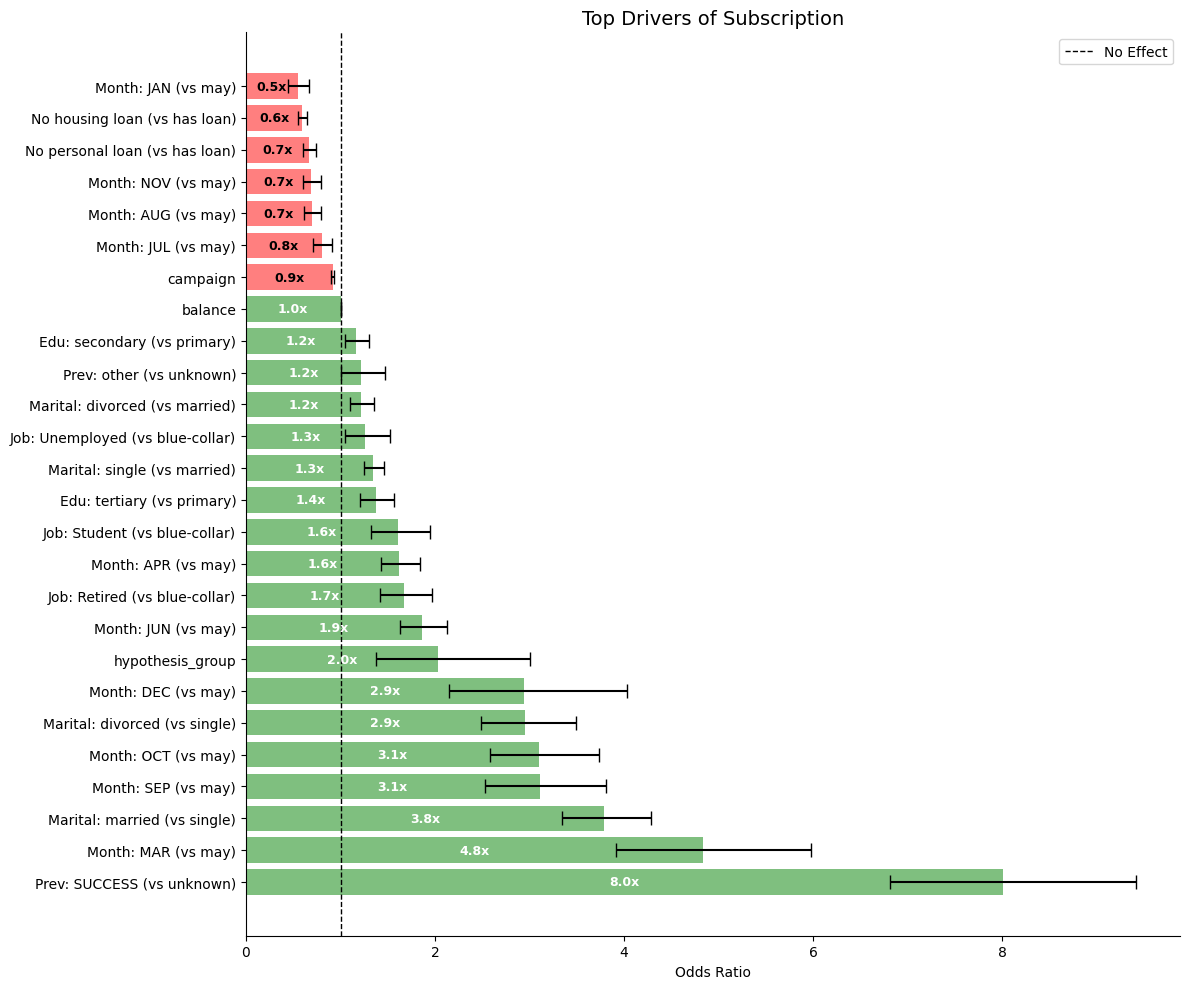

In [74]:
import matplotlib.pyplot as plt

# Use the significant results with odds ratios and CIs
plot_data = significant_results.sort_values('Odds_Ratio', ascending=False)

# Plot horizontal bar chart
plt.figure(figsize=(12, 10))
colors = ['green' if x > 1 else 'red' for x in plot_data['Odds_Ratio']]
bars = plt.barh(range(len(labels)), plot_data['Odds_Ratio'],
         xerr=[plot_data['Odds_Ratio'] - plot_data['CI_Lower'],
               plot_data['CI_Upper'] - plot_data['Odds_Ratio']],
         color=colors, alpha=0.5, capsize=5)

plt.axvline(1, color='black', linestyle='--', linewidth=1, label='No Effect')
plt.xlabel('Odds Ratio')
plt.title('Top Drivers of Subscription', fontsize=14)
plt.yticks(range(len(labels)), labels, fontsize=10)
plt.legend()

# # Add value annotations on bars
for i, (bar, odds_ratio) in enumerate(zip(bars, plot_data['Odds_Ratio'])):
    width = bar.get_width()
    plt.text(width/2, bar.get_y() + bar.get_height()/2, f'{odds_ratio:.1f}x',
             ha='center', va='center', color='white' if odds_ratio > 1 else 'black', fontsize=9, fontweight='bold')


plt.tight_layout()
plt.show()

#### Overall Marketing implications

1. Previous campaign success dominates — clients who have subscribed before are almost 10x more likely to subscribe again than unknown-outcome clients. Do not re-target clients who rejected previous campaigns as it strongly predicts future rejection.

2. Timing is critical — March, September, October, December are high-converting months. Campaign investments should be concentrated in these periods, while low-performing months may require either reduced spending or different campaign messaging.

3. Contact method matters — cellular > telephone > unknown. Campaigns should shift toward phone-based communication, especially during peak months.

4. Demographics matter moderately — retired, students, higher education, single/divorced clients more likely to subscribe. Campaigns should use segmentation and personalized messaging for these groups, as they respond more favorably to long-term deposit products.

5. Loans have a small negative effect — clients without housing or personal loans are slightly less likely to subscribe. For instance, People without a housing loan are 40% less likely to subscribe compared to those with a housing loan.

6. More campaign attempts are correlated with lower success rates. Avoid excessive repeated contacts.

7. Balance matters, but moderately. Subscribers tend to have slightly higher balances, but this factor is not decisive on its own. Balance can be used as a secondary filter, not a primary driver of targeting strategy.
